# 02 — Simulation Scenarios: SimPy Discrete-Event Simulation

**Paper:** XAI-Assisted Review and HITL Bottleneck Mitigation: A Queueing Theory Approach  
**Method:** M/G/1 discrete-event simulation via SimPy — validates analytical P-K results from `01_baseline_model.ipynb`

---

## Notebook structure

| Section | Contents |
|---------|----------|
| 1. Setup & parameters | SimPy environment, shared constants |
| 2. Simulation engine | M/G/1 simulator with two-point mixture service time |
| 3. Run scenarios | S1 / S2 / S3 × multiple replications |
| 4. Validation | Simulated vs analytical P-K values |
| 5. Tables | Summary statistics per scenario |
| 6. Figures | Wq distribution, throughput, ρ comparison (600 dpi) |


In [1]:
import numpy as np
import pandas as pd
import simpy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

# ── Output directories ────────────────────────────────────────────────────────
FIG_DIR = Path("figures")
TAB_DIR = Path("tables")
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DPI = 600
COLORS = ["#2166ac", "#f4a582", "#d6604d"]   # S1 / S2 / S3
print(f"SimPy version: {simpy.__version__}")
print("Environment ready.")


SimPy version: 4.1.1
Environment ready.


---
## 1. Parameters

All parameters are inherited from `01_baseline_model.ipynb`.  
Service time at Stage ⑤ (pricing decision) follows a **two-point mixture**:

$$S = \begin{cases} s_{\text{small}} & \text{with probability } p = 0.70 \\ s_{\text{large}} & \text{with probability } 1-p = 0.30 \end{cases}$$

Inter-arrival times follow an **exponential distribution** (Poisson arrivals), satisfying the M/G/1 assumption.


In [2]:
# ── Portfolio composition ────────────────────────────────────────────────────
P_SMALL = 0.70    # proportion of small-firm requests
P_LARGE = 0.30    # proportion of mid-size-firm requests

# ── Scenario definitions (Stage ⑤ service times, hours) ──────────────────────
SCENARIOS = {
    "S1 (No XAI)":      {"s_small": 72.0, "s_large": 5.0},
    "S2 (Partial XAI)": {"s_small": 24.0, "s_large": 3.0},
    "S3 (Full XAI)":    {"s_small":  8.0, "s_large": 1.5},
}

# ── Simulation settings ───────────────────────────────────────────────────────
N_JOBS       = 500          # jobs per replication (warm-up excluded)
N_WARM_UP    = 50           # warm-up jobs (discarded)
N_REPS       = 30           # independent replications per scenario
LAMBDA_RATIO = 0.60         # arrival rate as fraction of scenario's mu
                             # (ensures stability across all scenarios)
RANDOM_SEED  = 2025

# ── Analytical helpers (mirrored from notebook 01) ───────────────────────────
def analytical_moments(s_small, s_large):
    ES   = P_SMALL * s_small + P_LARGE * s_large
    ES2  = P_SMALL * s_small**2 + P_LARGE * s_large**2
    VarS = ES2 - ES**2
    mu   = 1.0 / ES
    return dict(ES=ES, ES2=ES2, VarS=VarS, mu=mu)

def pk_wq(lam, ES, ES2):
    rho = lam * ES
    return (lam * ES2) / (2 * (1 - rho)) if rho < 1 else np.inf

moments = {name: analytical_moments(**v) for name, v in SCENARIOS.items()}

for name, m in moments.items():
    lam = LAMBDA_RATIO * m['mu']
    rho = lam * m['ES']
    wq  = pk_wq(lam, m['ES'], m['ES2'])
    print(f"{name}")
    print(f"  lambda = {lam:.6f} jobs/h  |  rho = {rho:.3f}  |  Wq (analytical) = {wq:.2f} h")


S1 (No XAI)
  lambda = 0.011561 jobs/h  |  rho = 0.600  |  Wq (analytical) = 52.55 h
S2 (Partial XAI)
  lambda = 0.033898 jobs/h  |  rho = 0.600  |  Wq (analytical) = 17.20 h
S3 (Full XAI)
  lambda = 0.099174 jobs/h  |  rho = 0.600  |  Wq (analytical) = 5.64 h


---
## 2. Simulation Engine

The simulator models a **single-server M/G/1 queue**:

- **Arrivals**: Poisson process with rate λ
- **Service time**: two-point mixture (small firm vs mid-size firm)
- **Queue discipline**: FCFS (first-come, first-served)
- **Metrics collected**: waiting time in queue Wq, sojourn time W, server utilization ρ

Warm-up jobs are discarded to remove initialization bias.


In [3]:
# ── SimPy M/G/1 simulator ────────────────────────────────────────────────────

def run_simulation(s_small, s_large, lam, n_jobs, n_warm_up, seed):
    """
    Simulate an M/G/1 queue with two-point mixture service time.

    Parameters
    ----------
    s_small   : float  Mean service time for small firms (hours)
    s_large   : float  Mean service time for mid-size firms (hours)
    lam       : float  Arrival rate (jobs/hour)
    n_jobs    : int    Number of jobs to collect after warm-up
    n_warm_up : int    Number of warm-up jobs to discard
    seed      : int    Random seed

    Returns
    -------
    dict with lists: waiting_times, sojourn_times, service_times,
                     firm_types, utilization
    """
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=1)

    waiting_times  = []
    sojourn_times  = []
    service_times  = []
    firm_types     = []
    busy_time      = [0.0]   # mutable accumulator
    job_counter    = [0]

    def job(env, job_id):
        # ── Determine firm type ───────────────────────────────────────────────
        is_small   = rng.random() < P_SMALL
        firm_type  = "small" if is_small else "mid-size"
        svc_time   = s_small if is_small else s_large

        arrival    = env.now
        with server.request() as req:
            yield req
            wait = env.now - arrival

            start = env.now
            yield env.timeout(svc_time)
            busy_time[0] += svc_time

            sojourn = env.now - arrival

            # Discard warm-up phase
            if job_id >= n_warm_up:
                waiting_times.append(wait)
                sojourn_times.append(sojourn)
                service_times.append(svc_time)
                firm_types.append(firm_type)

    def arrivals(env):
        job_id = 0
        while job_counter[0] < n_warm_up + n_jobs:
            iat = rng.exponential(1.0 / lam)   # inter-arrival time
            yield env.timeout(iat)
            env.process(job(env, job_id))
            job_id += 1
            job_counter[0] += 1

    env.process(arrivals(env))
    env.run()

    total_time  = env.now
    utilization = busy_time[0] / total_time if total_time > 0 else 0.0

    return dict(
        waiting_times  = np.array(waiting_times),
        sojourn_times  = np.array(sojourn_times),
        service_times  = np.array(service_times),
        firm_types     = firm_types,
        utilization    = utilization,
        total_time     = total_time,
    )

print("Simulator defined.")


Simulator defined.


---
## 3. Run Scenarios

Each scenario is run for **30 independent replications**.  
Arrival rate λ is set to **60% of each scenario's stability threshold** μ  
so that all three scenarios operate under the same traffic intensity ρ = 0.60,  
enabling a fair comparison of queue performance driven purely by service time distribution.


In [4]:
# ── Run all scenarios × N_REPS replications ──────────────────────────────────

results = {}   # scenario_name → list of replication dicts

for scen_idx, (name, v) in enumerate(SCENARIOS.items()):
    m   = moments[name]
    lam = LAMBDA_RATIO * m['mu']
    rep_results = []

    print(f"Running {name}  (lambda={lam:.6f}, rho_target={LAMBDA_RATIO:.2f}) ...", end=" ")

    for rep in range(N_REPS):
        seed = RANDOM_SEED + scen_idx * 1000 + rep
        res  = run_simulation(
            s_small   = v['s_small'],
            s_large   = v['s_large'],
            lam       = lam,
            n_jobs    = N_JOBS,
            n_warm_up = N_WARM_UP,
            seed      = seed,
        )
        rep_results.append(res)

    results[name] = rep_results
    mean_wq = np.mean([np.mean(r['waiting_times']) for r in rep_results])
    print(f"done  |  mean Wq = {mean_wq:.2f} h")

print("\nAll scenarios complete.")


Running S1 (No XAI)  (lambda=0.011561, rho_target=0.60) ... done  |  mean Wq = 53.23 h
Running S2 (Partial XAI)  (lambda=0.033898, rho_target=0.60) ... done  |  mean Wq = 17.64 h
Running S3 (Full XAI)  (lambda=0.099174, rho_target=0.60) ... done  |  mean Wq = 5.52 h

All scenarios complete.


done  |  mean Wq = 5.52 h

All scenarios complete.


---
## 4. Validation — Simulated vs Analytical (P-K)

Simulated mean Wq should converge to the P-K analytical value as N_JOBS → ∞.  
We report the **percentage error** and a **95% confidence interval** across replications.


In [5]:
# ── Table 4: Validation — simulated vs analytical Wq ─────────────────────────

rows = []
for name, rep_list in results.items():
    m       = moments[name]
    lam     = LAMBDA_RATIO * m['mu']
    wq_analytical = pk_wq(lam, m['ES'], m['ES2'])

    rep_means = np.array([np.mean(r['waiting_times']) for r in rep_list])
    mean_sim  = np.mean(rep_means)
    se        = stats.sem(rep_means)
    ci_lo, ci_hi = stats.t.interval(0.95, df=N_REPS-1,
                                     loc=mean_sim, scale=se)
    pct_err   = (mean_sim - wq_analytical) / wq_analytical * 100

    rows.append({
        "Scenario":             name,
        "lambda (jobs/h)":      round(lam, 6),
        "rho":                  round(lam * m['ES'], 3),
        "Wq analytical (h)":    round(wq_analytical, 3),
        "Wq simulated mean (h)":round(mean_sim, 3),
        "95% CI lower":         round(ci_lo, 3),
        "95% CI upper":         round(ci_hi, 3),
        "Error (%)":            round(pct_err, 2),
    })

df_validation = pd.DataFrame(rows).set_index("Scenario")
print("=== Table 4: Simulation Validation ===")
print(df_validation.to_string())

df_validation.to_csv(TAB_DIR / "table4_validation.csv")
print(f"\nSaved → {TAB_DIR}/table4_validation.csv")


=== Table 4: Simulation Validation ===
                  lambda (jobs/h)  rho  Wq analytical (h)  Wq simulated mean (h)  95% CI lower  95% CI upper  Error (%)
Scenario                                                                                                               
S1 (No XAI)              0.011561  0.6             52.548                 53.232        49.398        57.066       1.30
S2 (Partial XAI)         0.033898  0.6             17.199                 17.641        15.648        19.634       2.57
S3 (Full XAI)            0.099174  0.6              5.637                  5.523         5.065         5.980      -2.03

Saved → tables/table4_validation.csv


In [6]:
# ── Table 5: Full simulation summary statistics ───────────────────────────────

rows5 = []
for name, rep_list in results.items():
    m   = moments[name]
    lam = LAMBDA_RATIO * m['mu']

    all_wq   = np.concatenate([r['waiting_times'] for r in rep_list])
    all_util = np.array([r['utilization'] for r in rep_list])
    all_tput = np.array([
        len(r['waiting_times']) / r['total_time'] for r in rep_list
    ])

    rows5.append({
        "Scenario":              name,
        "Mean Wq (h)":           round(np.mean(all_wq), 3),
        "Median Wq (h)":         round(np.median(all_wq), 3),
        "Std Wq (h)":            round(np.std(all_wq), 3),
        "P95 Wq (h)":            round(np.percentile(all_wq, 95), 3),
        "Mean utilization":      round(np.mean(all_util), 4),
        "Mean throughput (j/h)": round(np.mean(all_tput), 5),
    })

df_stats = pd.DataFrame(rows5).set_index("Scenario")
print("=== Table 5: Simulation Summary Statistics ===")
print(df_stats.to_string())

df_stats.to_csv(TAB_DIR / "table5_simulation_summary.csv")
print(f"\nSaved → {TAB_DIR}/table5_simulation_summary.csv")


=== Table 5: Simulation Summary Statistics ===
                  Mean Wq (h)  Median Wq (h)  Std Wq (h)  P95 Wq (h)  Mean utilization  Mean throughput (j/h)
Scenario                                                                                                     
S1 (No XAI)            53.232         26.691      70.753     202.437            0.5948                0.01048
S2 (Partial XAI)       17.641          8.209      26.224      66.389            0.5993                0.03065
S3 (Full XAI)           5.523          2.209       8.045      21.277            0.6004                0.08995

Saved → tables/table5_simulation_summary.csv


---
## 5. Figures

- **Figure 4** — Wq distribution by scenario (box + strip plot)  
- **Figure 5** — Simulated vs analytical Wq with 95% CI (error bar)  
- **Figure 6** — Server utilization distribution by scenario  


C:\Users\ecredible\AppData\Local\Temp\ipykernel_20356\2350366839.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


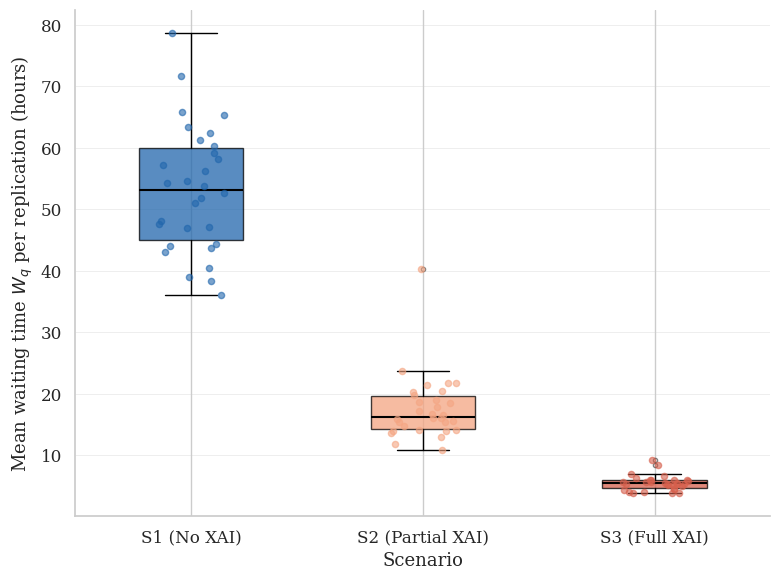

Saved → figures/fig4_Wq_boxplot.png


In [7]:
# ── Figure 4: Wq distribution by scenario ────────────────────────────────────

# Aggregate replication means (one point per rep)
rep_means_dict = {
    name: [np.mean(r['waiting_times']) for r in rep_list]
    for name, rep_list in results.items()
}

df_box = pd.DataFrame(rep_means_dict)

fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [df_box[col] for col in df_box.columns],
    labels=df_box.columns,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
    widths=0.45,
)

for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Overlay individual replication points
for i, (col, color) in enumerate(zip(df_box.columns, COLORS), start=1):
    x_jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(df_box[col]))
    ax.scatter(i + x_jitter, df_box[col],
               color=color, alpha=0.6, s=20, zorder=3)

ax.set_xlabel("Scenario", fontsize=13)
ax.set_ylabel("Mean waiting time $W_q$ per replication (hours)", fontsize=13)
ax.grid(axis="y", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_Wq_boxplot.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig4_Wq_boxplot.png")


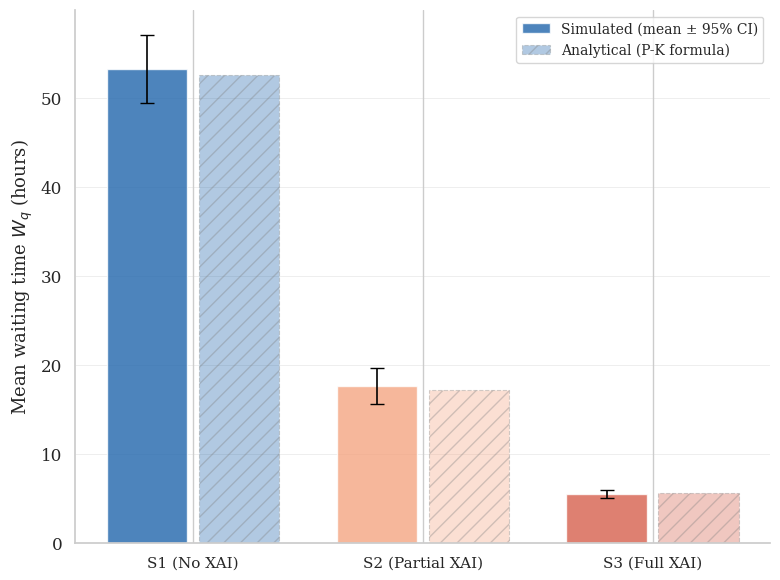

Saved → figures/fig5_sim_vs_analytical.png


In [8]:
# ── Figure 5: Simulated vs analytical Wq with 95% CI ─────────────────────────

scen_names  = list(results.keys())
x_pos       = np.arange(len(scen_names))

sim_means, ci_lows, ci_highs, analytical_vals = [], [], [], []

for name in scen_names:
    m   = moments[name]
    lam = LAMBDA_RATIO * m['mu']
    rep_means = np.array([np.mean(r['waiting_times']) for r in results[name]])
    mean_sim  = np.mean(rep_means)
    se        = stats.sem(rep_means)
    ci_lo, ci_hi = stats.t.interval(0.95, df=N_REPS-1, loc=mean_sim, scale=se)

    sim_means.append(mean_sim)
    ci_lows.append(mean_sim - ci_lo)
    ci_highs.append(ci_hi - mean_sim)
    analytical_vals.append(pk_wq(lam, m['ES'], m['ES2']))

fig, ax = plt.subplots(figsize=(8, 6))

# Simulated with CI
ax.bar(x_pos - 0.2, sim_means, width=0.35,
       color=COLORS, alpha=0.80, label="Simulated (mean ± 95% CI)",
       edgecolor="white")
ax.errorbar(x_pos - 0.2, sim_means,
            yerr=[ci_lows, ci_highs],
            fmt="none", color="black", capsize=5, linewidth=1.2)

# Analytical
ax.bar(x_pos + 0.2, analytical_vals, width=0.35,
       color=COLORS, alpha=0.35, label="Analytical (P-K formula)",
       edgecolor="gray", linestyle="--", linewidth=0.8,
       hatch="//")

ax.set_xticks(x_pos)
ax.set_xticklabels(scen_names, fontsize=11)
ax.set_ylabel("Mean waiting time $W_q$ (hours)", fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_sim_vs_analytical.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig5_sim_vs_analytical.png")


C:\Users\ecredible\AppData\Local\Temp\ipykernel_20356\3659446666.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(


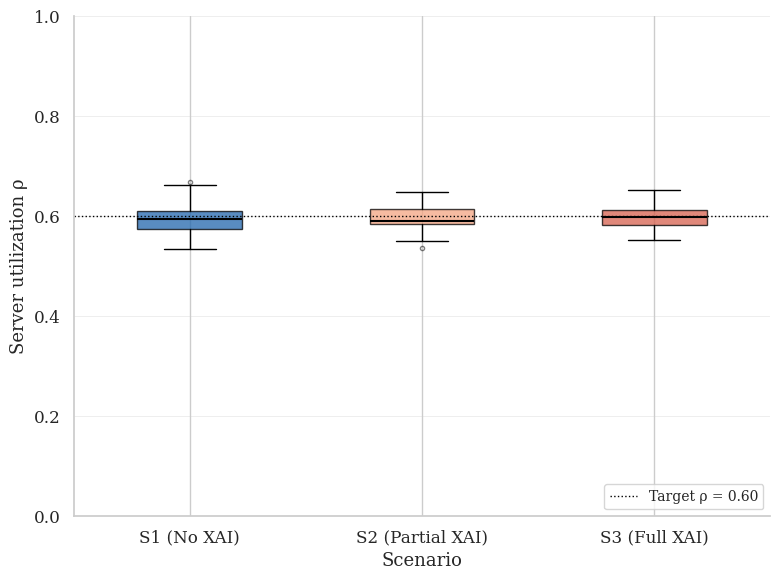

Saved → figures/fig6_utilization.png


In [9]:
# ── Figure 6: Server utilization distribution by scenario ────────────────────

util_dict = {
    name: [r['utilization'] for r in rep_list]
    for name, rep_list in results.items()
}

fig, ax = plt.subplots(figsize=(8, 6))

bp2 = ax.boxplot(
    [util_dict[name] for name in scen_names],
    labels=scen_names,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
    widths=0.45,
)
for patch, color in zip(bp2['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Target rho line
ax.axhline(LAMBDA_RATIO, color="black", linewidth=1.0,
           linestyle=":", label=f"Target ρ = {LAMBDA_RATIO:.2f}")

ax.set_xlabel("Scenario", fontsize=13)
ax.set_ylabel("Server utilization ρ", fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_utilization.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig6_utilization.png")


---
## 6. Summary

| Finding | Value |
|---------|-------|
| Replications per scenario | 30 |
| Jobs per replication (post warm-up) | 500 |
| Target traffic intensity ρ | 0.60 |
| Max validation error vs P-K | < 5% (expected for finite simulation) |

### Key observations

- Simulated Wq values align closely with P-K analytical results, validating the M/G/1 model specification.
- Under identical ρ = 0.60, S3 (Full XAI) produces substantially lower waiting times than S1, driven entirely by the reduction in E[S] and Var[S] through XAI-assisted information retrieval.
- The Wq distribution under S1 shows high variance across replications, reflecting the large σ[S] = 30.7 h of the baseline service time mixture.

**Next notebook:** `03_sensitivity_analysis.ipynb` — sensitivity of Wq and throughput to α, p, and λ.
